# LLaVA-OneVision Multi-Image Fine-Tuning for Litter Detection

This notebook shows how fine-tunes llava-hf/llava-onevision-qwen2-0.5b-ov-hf on the custom litter dataset where each sample contains one context image plus one or more crop images.

This also mirrors the Qwen2.5-VL notebook so we can compare models fairly on the same task and evaluation flow.

## 1. Install Dependencies

In [2]:
%pip install -U transformers trl datasets peft bitsandbytes accelerate pillow tensorboard sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.0/531.0 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 52.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
     

## Mount Google Drive in Colab

In [1]:
 from google.colab import drive
 drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuration

In [2]:
from pathlib import Path

DATA_ROOT = Path('/content/drive/MyDrive/Qwen updated')
TRAIN_FILE = DATA_ROOT / 'train.jsonl'
VAL_FILE = DATA_ROOT / 'val.jsonl'
TEST_FILE = DATA_ROOT / 'test.jsonl'

MODEL_ID = 'llava-hf/llava-onevision-qwen2-0.5b-ov-hf'


OUTPUT_DIR = Path('/content/drive/MyDrive/outputs/llava-onevision-litter-multiimage')

MAX_TRAIN_SAMPLES = None
MAX_EVAL_SAMPLES = None
MAX_CROPS_PER_SAMPLE = 6
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
LEARNING_RATE = 1e-4
LOGGING_STEPS = 5
SAVE_STEPS = 100
EVAL_STEPS = 100
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
SEED = 42

assert TRAIN_FILE.exists(), f'Missing {TRAIN_FILE}'
assert VAL_FILE.exists(), f'Missing {VAL_FILE}'
assert TEST_FILE.exists(), f'Missing {TEST_FILE}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Data root:', DATA_ROOT)
print('Model:', MODEL_ID)
print('Output dir:', OUTPUT_DIR)

Data root: /content/drive/MyDrive/Qwen updated
Model: llava-hf/llava-onevision-qwen2-0.5b-ov-hf
Output dir: /content/drive/MyDrive/outputs/llava-onevision-litter-multiimage


## 4. Imports and Runtime Check

In [3]:
import json
import random

import torch
from PIL import Image
from datasets import DatasetDict, load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    LlavaOnevisionForConditionalGeneration,
    set_seed,
)
from trl import SFTConfig, SFTTrainer

set_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required for LLaVA-OneVision fine-tuning.')

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print('CUDA:', torch.cuda.get_device_name(0))
print('Compute dtype:', DTYPE)

CUDA: NVIDIA A100-SXM4-40GB
Compute dtype: torch.bfloat16


## 5. Load the JSONL Dataset

In [4]:
raw_ds = load_dataset(
    'json',
    data_files={
        'train': str(TRAIN_FILE),
        'validation': str(VAL_FILE),
        'test': str(TEST_FILE),
    },
)

if MAX_TRAIN_SAMPLES is not None:
    raw_ds['train'] = raw_ds['train'].select(range(min(MAX_TRAIN_SAMPLES, len(raw_ds['train']))))
if MAX_EVAL_SAMPLES is not None:
    raw_ds['validation'] = raw_ds['validation'].select(range(min(MAX_EVAL_SAMPLES, len(raw_ds['validation']))))

raw_ds

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 774
    })
    validation: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 97
    })
    test: Dataset({
        features: ['images', 'instruction', 'output'],
        num_rows: 97
    })
})

In [5]:
print(json.dumps(raw_ds['train'][0], indent=2))

{
  "images": [
    {
      "uri": "full_images/Hygiene_105.jpg",
      "role": "context"
    },
    {
      "uri": "processed_full/crops/hygiene_Hygiene_105_00.jpg",
      "role": "crop"
    }
  ],
  "instruction": "Analyze the scene image together with the crop images.\n\nReturn ONLY JSON using this exact format:\n\n{\n \"counts\":{\n   \"food_drink\":int,\n   \"smoking\":int,\n   \"hygiene\":int,\n   \"waste\":int,\n   \"animal\":int,\n   \"hazard\":int\n },\n \"visual_density\":\"low|medium|high\",\n \"spatial_distribution\":\"clustered|scattered\",\n \"perception_score\":1-5,\n \"confidence\":0-1\n}",
  "output": {
    "counts": {
      "food_drink": 0,
      "smoking": 0,
      "hygiene": 1,
      "waste": 0,
      "animal": 0,
      "hazard": 0
    },
    "visual_density": "low",
    "spatial_distribution": "scattered",
    "perception_score": 1,
    "confidence": 0.9
  }
}


## 6. Convert Rows into Multi-Image Chat Samples

In [7]:
SYSTEM_PROMPT = (
    "You are a careful litter analysis assistant. Use the context image and all crop images together. "
    "Return only valid JSON that exactly follows the requested schema."
)

def resolve_image_path(uri: str) -> str:
    path = DATA_ROOT / uri
    if not path.exists():
        raise FileNotFoundError(f"Missing image: {path}")
    return str(path)

def is_valid_image(path: str) -> bool:
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            return img.width >= 8 and img.height >= 8
    except Exception:
        return False

def build_user_content(images, instruction):
    content = [
        {"type": "text", "text": instruction.strip()},
        {"type": "text", "text": "Context image:"},
    ]

    context_images = [img for img in images if img.get("role") == "context"]
    crop_images = [img for img in images if img.get("role") == "crop"]

    for _ in context_images:
        content.append({"type": "image"})

    for idx, _ in enumerate(crop_images, start=1):
        content.append({"type": "text", "text": f"Crop image {idx}:"})
        content.append({"type": "image"})

    return content

def format_example(example):
    context_images = [img for img in example["images"] if img.get("role") == "context"]
    crop_images = [img for img in example["images"] if img.get("role") != "context"]

    if MAX_CROPS_PER_SAMPLE is not None:
        crop_images = crop_images[:MAX_CROPS_PER_SAMPLE]

    ordered_images = context_images + crop_images

    valid_images = []
    image_paths = []

    for img in ordered_images:
        path = resolve_image_path(img["uri"])
        if is_valid_image(path):
            valid_images.append(img)
            image_paths.append(path)

    if not image_paths:
        raise ValueError("Sample has no valid images after filtering.")

    assistant_text = json.dumps(example["output"], ensure_ascii=True, separators=(",", ":"))

    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": build_user_content(valid_images, example["instruction"]),
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": assistant_text}],
        },
    ]

    return {
        "messages": messages,
        "image_paths": image_paths,
        "target_text": assistant_text,
        "num_images": len(image_paths),
    }

formatted_ds = DatasetDict({
    split: raw_ds[split].map(format_example, remove_columns=raw_ds[split].column_names)
    for split in raw_ds.keys()
})

formatted_ds


DatasetDict({
    train: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 774
    })
    validation: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 97
    })
    test: Dataset({
        features: ['messages', 'image_paths', 'target_text', 'num_images'],
        num_rows: 97
    })
})

In [8]:
sample = formatted_ds['train'][0]
print('num_images:', sample['num_images'])
print('image_paths:')
for p in sample['image_paths']:
    print(' -', p)
print('\nassistant target:')
print(sample['target_text'])

num_images: 2
image_paths:
 - /content/drive/MyDrive/Qwen updated/full_images/Hygiene_105.jpg
 - /content/drive/MyDrive/Qwen updated/processed_full/crops/hygiene_Hygiene_105_00.jpg

assistant target:
{"counts":{"food_drink":0,"smoking":0,"hygiene":1,"waste":0,"animal":0,"hazard":0},"visual_density":"low","spatial_distribution":"scattered","perception_score":1,"confidence":0.9}


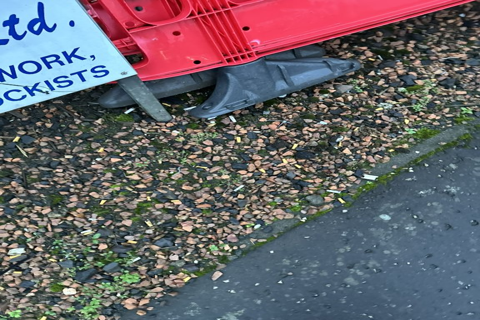

{"counts":{"food_drink":0,"smoking":9,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"high","spatial_distribution":"scattered","perception_score":4,"confidence":0.9}


In [9]:
preview_idx = random.randrange(len(formatted_ds['train']))
preview = formatted_ds['train'][preview_idx]
display(Image.open(preview['image_paths'][0]).convert('RGB').resize((480, 320)))
print(preview['target_text'])

## 7. Load Processor and QLoRA Model

In [10]:
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=True)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=DTYPE,
)

model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    MODEL_ID,
    device_map='auto',
    torch_dtype=DTYPE,
    quantization_config=bnb_config,
)

model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    target_modules='all-linear',
    task_type='CAUSAL_LM',
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/178 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/621 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/716 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

trainable params: 17,232,896 || all params: 910,908,448 || trainable%: 1.8918


## 8. Collator for Multi-Image Supervised Fine-Tuning

In [21]:
def safe_load_rgb(path: str):
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            if img.width < 8 or img.height < 8:
                return None
            return img
    except Exception:
        return None

def find_image_token_ids(processor):
    token_ids = set()
    tokenizer = processor.tokenizer
    for token in ["<image>", "<|image_pad|>", "<|vision_start|>", "<|vision_end|>"]:
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id is not None and token_id != tokenizer.unk_token_id:
            token_ids.add(token_id)
    return token_ids

def collate_fn(examples):
    image_token_ids = find_image_token_ids(processor)

    valid_texts = []
    valid_images = []

    for example in examples:
        imgs = [safe_load_rgb(path) for path in example["image_paths"]]
        imgs = [img for img in imgs if img is not None]

        if len(imgs) == 0:
            continue

        text = processor.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False,
        )

        valid_texts.append(text)
        valid_images.append(imgs)

    if len(valid_texts) == 0:
        raise ValueError("All images in this batch were invalid or too small.")

    batch = processor(
        text=valid_texts,
        images=valid_images,
        padding=True,
        return_tensors="pt",
    )

    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100

    for token_id in image_token_ids:
        labels[labels == token_id] = -100

    batch["labels"] = labels
    return batch


## 9. Trainer Setup

In [12]:
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=LOGGING_STEPS,
    save_steps=SAVE_STEPS,
    eval_steps=EVAL_STEPS,
    eval_strategy='steps',
    save_strategy='steps',
    bf16=(DTYPE == torch.bfloat16),
    fp16=(DTYPE == torch.float16),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={'use_reentrant': False},
    lr_scheduler_type='cosine',
    warmup_ratio=0.03,
    max_length=None,
    dataset_kwargs={'skip_prepare_dataset': True},
    remove_unused_columns=False,
    report_to='tensorboard',
    dataloader_num_workers=0,
    seed=SEED,
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted_ds['train'],
    eval_dataset=formatted_ds['validation'],
    data_collator=collate_fn,
    processing_class=processor,
)

trainer

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 10. Train

In [13]:
train_result = trainer.train()
train_result

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
100,0.021202,0.019734
200,0.013233,0.011880
300,0.010516,0.012841
400,0.005126,0.011605
500,0.004874,0.010777


TrainOutput(global_step=582, training_loss=0.11668993120923433, metrics={'train_runtime': 2717.9073, 'train_samples_per_second': 0.854, 'train_steps_per_second': 0.214, 'total_flos': 3.039472319352192e+16, 'train_loss': 0.11668993120923433})

In [14]:
trainer.save_model()
processor.save_pretrained(OUTPUT_DIR)
print('Saved adapter and processor to', OUTPUT_DIR)

Saved adapter and processor to /content/drive/MyDrive/outputs/llava-onevision-litter-multiimage


## 11. Quick Validation Inference

In [3]:
model.eval()

val_example = formatted_ds['validation'][6]
prompt_messages = val_example['messages'][:-1]
prompt_text = processor.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)
prompt_images = [safe_load_rgb(path) for path in val_example['image_paths']]

inputs = processor(text=[prompt_text], images=[prompt_images], return_tensors='pt', padding=True)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():
    generated = model.generate(**inputs, max_new_tokens=256, do_sample=False)

input_len = inputs['input_ids'].shape[1]
generated_only = generated[:, input_len:]
generated_text = processor.batch_decode(generated_only, skip_special_tokens=True)[0].strip()

print('MODEL OUTPUT:\n')
print(generated_text)
print('\nTARGET JSON:\n')
print(val_example['target_text'])

NameError: name 'model' is not defined

## 12. Dominant Litter Source Accuracy

In [4]:
import json
from tqdm.auto import tqdm

SPLIT = 'test'
MAX_SAMPLES = None
COUNT_KEYS = ['food_drink', 'smoking', 'hygiene', 'waste', 'animal', 'hazard']

def dominant_litter_source(obj):
    counts = obj['counts']
    max_value = max(counts[k] for k in COUNT_KEYS)
    winners = [k for k in COUNT_KEYS if counts[k] == max_value]
    if max_value == 0:
        return 'none'
    if len(winners) > 1:
        return 'tie'
    return winners[0]

def predict_example(example):
    prompt_messages = example['messages'][:-1]
    prompt_text = processor.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_images = [safe_load_rgb(path) for path in example['image_paths']]

    inputs = processor(
        text=[prompt_text],
        images=[prompt_images],
        return_tensors='pt',
        padding=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    input_len = inputs['input_ids'].shape[1]
    generated_only = generated[:, input_len:]

    return processor.batch_decode(generated_only, skip_special_tokens=True)[0].strip()

dataset = formatted_ds[SPLIT]
if MAX_SAMPLES is not None:
    dataset = dataset.select(range(min(MAX_SAMPLES, len(dataset))))

model.eval()
total = 0
valid_json = 0
correct = 0

for example in tqdm(dataset):
    pred_text = predict_example(example)
    true_obj = json.loads(example['target_text'])
    total += 1
    try:
        pred_obj = json.loads(pred_text)
        valid_json += 1
        if dominant_litter_source(pred_obj) == dominant_litter_source(true_obj):
            correct += 1
    except Exception:
        pass

print(f'Samples: {total}')
print(f'Valid JSON rate: {valid_json / total:.4f}')
print(f'Dominant litter source accuracy: {correct / total:.4f}')

NameError: name 'formatted_ds' is not defined

##Load finetuned model

In [1]:
import torch
from PIL import Image
from peft import PeftModel
from transformers import AutoProcessor, BitsAndBytesConfig, LlavaOnevisionForConditionalGeneration

BASE_MODEL_ID = "llava-hf/llava-onevision-qwen2-0.5b-ov-hf"
ADAPTER_PATH = "/content/drive/MyDrive/outputs/llava-onevision-litter-multiimage/checkpoint-582"

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=DTYPE,
)

processor = AutoProcessor.from_pretrained(ADAPTER_PATH, use_fast=True)

base_model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    device_map="auto",
    torch_dtype=DTYPE,
    quantization_config=bnb_config,
)

model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.79G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/716 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlavaOnevisionForConditionalGeneration(
      (model): LlavaOnevisionModel(
        (vision_tower): SiglipVisionModel(
          (vision_model): SiglipVisionTransformer(
            (embeddings): SiglipVisionEmbeddings(
              (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
              (position_embedding): Embedding(729, 1152)
            )
            (encoder): SiglipEncoder(
              (layers): ModuleList(
                (0-25): 26 x SiglipEncoderLayer(
                  (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                  (self_attn): SiglipAttention(
                    (k_proj): lora.Linear4bit(
                      (base_layer): Linear4bit(in_features=1152, out_features=1152, bias=True)
                      (lora_dropout): ModuleDict(
                        (default): Dropout(p=0.05, inplace=False)
                      )
   

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


test the trained model on random samples and display the images its using.


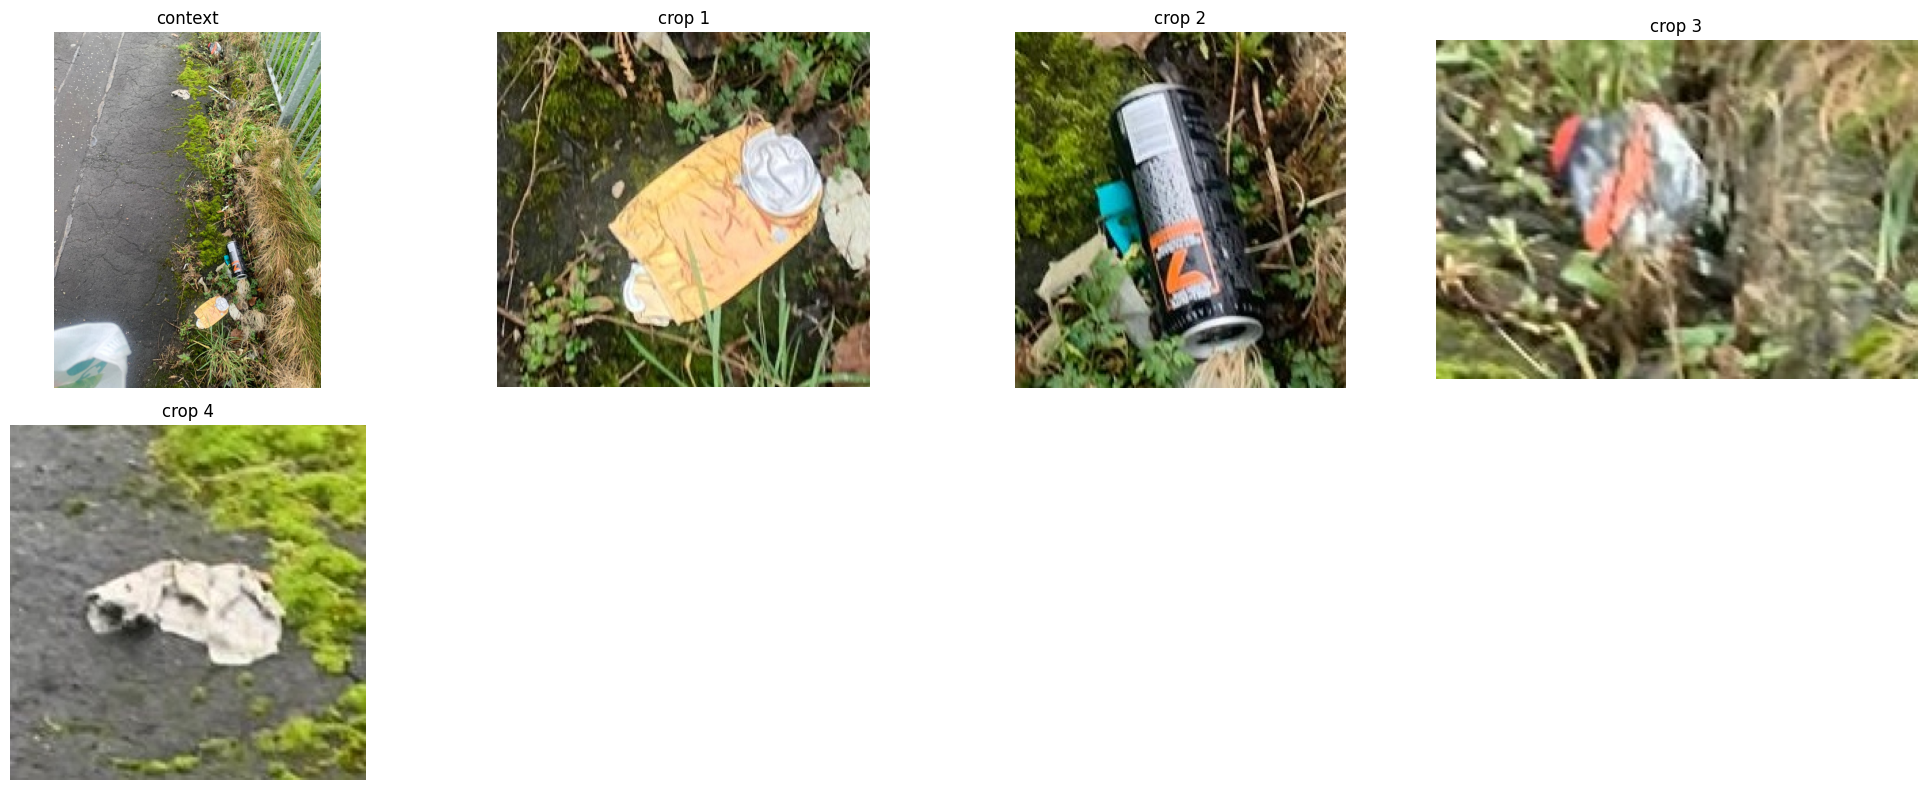

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Prediction:
{"counts":{"food_drink":3,"smoking":0,"hygiene":0,"waste":0,"animal":0,"hazard":0},"visual_density":"medium","spatial_distribution":"scattered","perception_score":3,"confidence":0.9}


In [3]:
import math
import matplotlib.pyplot as plt
from PIL import Image
import torch

SYSTEM_PROMPT = (
    "You are a careful litter analysis assistant. Use the context image and all crop images together. "
    "Return only valid JSON that exactly follows the requested schema."
)

context_path = "/content/drive/MyDrive/Litter and crops/images/7b5ff674-WhatsApp_Image_2025-12-19_at_12.37.53_PM_15.jpeg"
crop_paths = [
    "/content/drive/MyDrive/Litter and crops/crops/Litter_7b5ff674-WhatsApp_Image_2025-12-19_at_12.37.53_PM_15_ann59.jpg",
              "/content/drive/MyDrive/Litter and crops/crops/Litter_7b5ff674-WhatsApp_Image_2025-12-19_at_12.37.53_PM_15_ann60.jpg",
               "/content/drive/MyDrive/Litter and crops/crops/Litter_7b5ff674-WhatsApp_Image_2025-12-19_at_12.37.53_PM_15_ann62.jpg",
               "/content/drive/MyDrive/Litter and crops/crops/Litter_7b5ff674-WhatsApp_Image_2025-12-19_at_12.37.53_PM_15_ann61.jpg"

]
instruction = """Analyze the scene image together with the crop images. answer none as "True" is there is litter present and "False" if there is not.

Return ONLY JSON using this exact format:

{
 "counts":{
   "food_drink":int,
   "smoking":int,
   "hygiene":int,
   "waste":int,
   "animal":int,
   "hazard":int
 },
 "none":"True|False",
 "visual_density":"low|medium|high",
 "spatial_distribution":"clustered|scattered",
 "perception_score":1-5,
 "confidence":0-1
}"""

image_paths = [context_path] + crop_paths

def load_rgb(path: str):
    with Image.open(path) as img:
        return img.convert("RGB")

def show_images(image_paths):
    n = len(image_paths)
    cols = min(4, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for ax in axes[n:]:
        ax.axis("off")

    for i, path in enumerate(image_paths):
        img = load_rgb(path)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title("context" if i == 0 else f"crop {i}")

    plt.tight_layout()
    plt.show()

def build_user_content(num_crops, instruction):
    content = [
        {"type": "text", "text": instruction.strip()},
        {"type": "text", "text": "Context image:"},
        {"type": "image"},
    ]
    for i in range(num_crops):
        content.append({"type": "text", "text": f"Crop image {i+1}:"})
        content.append({"type": "image"})
    return content

show_images(image_paths)

messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": SYSTEM_PROMPT}],
    },
    {
        "role": "user",
        "content": build_user_content(len(crop_paths), instruction),
    },
]

prompt_text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

images = [load_rgb(p) for p in image_paths]

inputs = processor(
    text=[prompt_text],
    images=[images],
    return_tensors="pt",
    padding=True,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

model.eval()
with torch.no_grad():
    generated = model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
    )

input_len = inputs["input_ids"].shape[1]
generated_only = generated[:, input_len:]

result = processor.batch_decode(
    generated_only,
    skip_special_tokens=True
)[0].strip()

print("Prediction:")
print(result)


  0%|          | 0/97 [00:00<?, ?it/s]

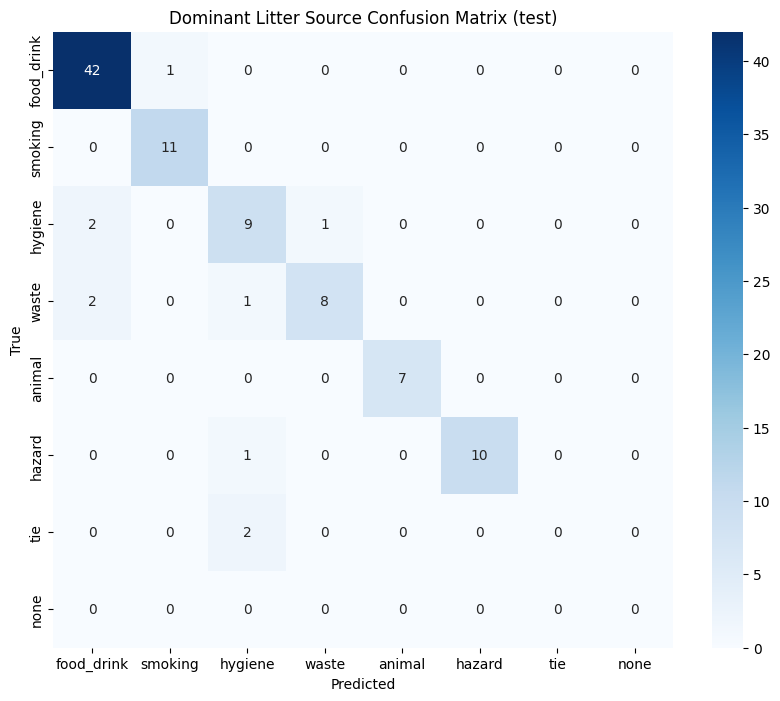

Classification Report:

              precision    recall  f1-score   support

  food_drink       0.91      0.98      0.94        43
     smoking       0.92      1.00      0.96        11
     hygiene       0.69      0.75      0.72        12
       waste       0.89      0.73      0.80        11
      animal       1.00      1.00      1.00         7
      hazard       1.00      0.91      0.95        11
         tie       0.00      0.00      0.00         2
        none       0.00      0.00      0.00         0

    accuracy                           0.90        97
   macro avg       0.68      0.67      0.67        97
weighted avg       0.88      0.90      0.89        97

Invalid JSON predictions: 0


In [45]:
import json
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

SPLIT = "test"
COUNT_KEYS = ["food_drink", "smoking", "hygiene", "waste", "animal", "hazard"]
LABEL_ORDER = ["food_drink", "smoking", "hygiene", "waste", "animal", "hazard", "tie", "none"]

def dominant_litter_source(obj):
    counts = obj["counts"]
    max_value = max(counts[k] for k in COUNT_KEYS)
    winners = [k for k in COUNT_KEYS if counts[k] == max_value]

    if max_value == 0:
        return "none"
    if len(winners) > 1:
        return "tie"
    return winners[0]

def predict_example(example):
    prompt_messages = example["messages"][:-1]
    prompt_text = processor.apply_chat_template(
        prompt_messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    prompt_images = [load_rgb(path) for path in example["image_paths"]]

    inputs = processor(
        text=[prompt_text],
        images=[prompt_images],
        return_tensors="pt",
        padding=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
        )

    input_len = inputs["input_ids"].shape[1]
    generated_only = generated[:, input_len:]

    return processor.batch_decode(
        generated_only,
        skip_special_tokens=True
    )[0].strip()

dataset = formatted_ds[SPLIT]

y_true = []
y_pred = []
bad_json = 0

model.eval()

for example in tqdm(dataset):
    true_obj = json.loads(example["target_text"])
    true_label = dominant_litter_source(true_obj)

    pred_text = predict_example(example)

    try:
        pred_obj = json.loads(pred_text)
        pred_label = dominant_litter_source(pred_obj)
    except Exception:
        pred_label = "invalid_json"
        bad_json += 1

    y_true.append(true_label)
    y_pred.append(pred_label)

labels_for_matrix = LABEL_ORDER + (["invalid_json"] if "invalid_json" in y_pred else [])

cm = confusion_matrix(y_true, y_pred, labels=labels_for_matrix)
cm_df = pd.DataFrame(cm, index=labels_for_matrix, columns=labels_for_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Dominant Litter Source Confusion Matrix ({SPLIT})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, labels=labels_for_matrix, zero_division=0))

print(f"Invalid JSON predictions: {bad_json}")
